In [1]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import scvi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os
import gc
from matplotlib.colors import to_hex
import anndata as ad
import scipy.sparse as sp


BASE = "/lustre/scratch124/cellgen/haniffa/projects/beacon/T/scrna_atlas_v2/"
out_dir = BASE


sc.settings.set_figure_params(dpi_save=50, facecolor="white", frameon=False, figsize=(20,20))
sc.settings.figdir = out_dir  

# #SAVE_PATH = '/lustre/scratch124/cellgen/haniffa/projects/beacon/nobackup_output//model_scanvi_2000genesV_plusIAv2_v10reint_5epochs_1997_epochs20/adata_all_scvi7.h5ad'
# SAVE_PATH='/lustre/scratch124/cellgen/haniffa/projects/beacon/nobackup_output/lineages_all2/adata_T.h5ad1500g_30EPOCHS_scanvi.clustered.clustered2'
# adata2=sc.read_h5ad(SAVE_PATH)

import pickle
with open("/nfs/team298/ls34/xenium_genes.pkl", "rb") as f:
    xenium_genes = pickle.load(f)         



hvg_number_target=1500
hvg_number=hvg_number_target
HVG_BATCH_KEY="sample_id"
run_scanvi=False
run_mrvi=False

BATCH_SIZE=512
N_LATENTS=10
N_LAYERS=1
neighbor=20
mindist=0.1
SCANVI_LABELS_KEY="xeniummap"  #"lvl5_annotation_new" #"lvl5_annotation2"
SCANVI_UNLABELLED= "new"

import os

/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MAX_EPOCHS=50

In [3]:
# PATH =  "/lustre/scratch124/cellgen/haniffa/projects/beacon/nobackup_output/adata_atlas_incxenium_v5.h5ad"
# adata=sc.read_h5ad(PATH)
# adata



In [4]:
# {x:x for x in adata.obs["tech"].unique()}

In [5]:
# RENAME = {'scrna': 'scrna', 'xenium': 'xenium', 'nan': 'xenium'}
# adata.obs["tech"]=adata.obs["tech"].map(RENAME)

In [6]:
# adata[adata.obs["final17"]=="Eosinophil"].shape

In [7]:
# adata[adata.obs["final17"]=="Eosinophil"].obs.Patient_status.value_counts()

In [8]:
# adata = adata[(adata.obs["final17"]=="Eosinophil")|
#              (adata.obs["final17"].str.startswith("Mast cell"))|
#               (adata.obs["final17"]=="Neutrophil")
#              ].copy()

In [9]:
# # Add "new" to the categories first
# adata.obs["final17"] = adata.obs["final17"].cat.add_categories("new")

# # Now create your combined column
# adata.obs["xeniummap"] = np.where(
#     adata.obs["tech"] != "scrna",
#     "new",
#     adata.obs["final17"]
# )

# # Optional: make categorical (already mostly categorical)
# adata.obs["xeniummap"] = adata.obs["xeniummap"].astype("category")

In [10]:
# PATH =  "/lustre/scratch124/cellgen/haniffa/projects/beacon/nobackup_output/adata_eosinophils_joint.h5ad"
# adata.write(PATH)

In [11]:
# stop

In [12]:
PATH =  "/lustre/scratch124/cellgen/haniffa/projects/beacon/nobackup_output/adata_eosinophils_joint.h5ad"
adata=sc.read_h5ad(PATH)

/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [13]:
import gc
gc.collect()

31

In [14]:
adata.obs.tech.value_counts()

tech
scrna     64450
xenium    18608
Name: count, dtype: int64

In [15]:
1

1

In [16]:
adata.obs["final17"].value_counts()

final17
Mast cell                   65595
Mast cell_Active_ABCC4hi     9500
Neutrophil                   6420
Eosinophil                   1310
Mast cell_prolif              233
new                             0
Name: count, dtype: int64

In [17]:
adata.obs["xeniummap"].value_counts()

xeniummap
Mast cell                   48961
new                         18608
Mast cell_Active_ABCC4hi     7564
Neutrophil                   6385
Eosinophil                   1309
Mast cell_prolif              231
Name: count, dtype: int64

In [18]:
run_scanvi

False

In [19]:
x="eosinophil_Scvi"
x=x.replace("/","_")
# Count occurrences
adata.obs[SCANVI_LABELS_KEY] = adata.obs[SCANVI_LABELS_KEY].astype("category")
try:
    adata.obs[SCANVI_LABELS_KEY] = (
        adata.obs[SCANVI_LABELS_KEY]
        .cat.add_categories(["new"])
)
except:
    1

# Count occurrences
counts = adata.obs[SCANVI_LABELS_KEY].value_counts()

# Identify rare labels
rare_labels = counts[counts < 10].index
# Replace rare labels
adata.obs.loc[
adata.obs[SCANVI_LABELS_KEY].isin(rare_labels),
SCANVI_LABELS_KEY
] = "new"

# Optional cleanup: remove unused categories
adata.obs[SCANVI_LABELS_KEY] = (
adata.obs[SCANVI_LABELS_KEY]
.cat.remove_unused_categories()
)
ADATA_PATH = BASE + f'adata_{x}.h5ad'


# count cells per sample_id
counts = adata.obs["sample_id"].value_counts()

# keep only sample_ids with >= 20 cells
keep_ids = counts[counts >= 2].index

# subset AnnData
adata = adata[adata.obs["sample_id"].isin(keep_ids)].copy()

adata.write(ADATA_PATH)


#adata=adata[adata.obs["final6"]!="FIBROBLAST PROGENITORS PDGFRA+"].copy()

#common_genes = [g for g in xenium_genes if g in adata.var_names]
#adata = adata[:, common_genes].copy()      # .copy() avoids chained-slice headaches




# if adata.shape[0] < 10_000:
#     neighbor=10
# else:

counts = adata.obs['sample_id'].value_counts()
small = counts[counts < 200].index.tolist()
mask = ~adata.obs['sample_id'].isin(small)
adata = adata[mask].copy()
adata.obs.sample_id.value_counts()
adata.obs["sample_id"] = adata.obs["sample_id"].astype("category")
adata.obs["sample_id"] = adata.obs["sample_id"].cat.remove_unused_categories()
sc.pp.filter_genes(adata, min_cells=10)
adata.shape


sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)



def apply_qc_thresholds(adata, MIN_N_GENES, MAX_TOTAL_COUNT, MAX_PCT_MT, label, MIN_TOTAL_COUNT=0,):
    """
    Apply thresholds to generate QC column which says if passed all
    """
    ## Cell cycle gene list
    cc_genes_csv=pd.read_csv('/nfs/team298/ls34/csv_files/cc_genes.csv',  names=["gene_ids"], skiprows=1)
    cc_genes_csv = cc_genes_csv["gene_ids"]
    cc_genes_csv = list(cc_genes_csv)
    # Mark MT/ribo/Hb/cell cycle genes
    adata.var['mt'] = adata.var_names.str.startswith('MT-')  
    adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
    adata.var["hb"] = adata.var_names.str.contains(("^HB[^(P)]")) 
    #adata.var["hb"] = adata.var_names.str.startswith(("HBA1", "HBA2", "HBB", "HBD","HBM", "HBZ", "HBG1", "HBG2", "HBQ1"))
    adata.var["cc_fetal"] = adata.var_names.isin(cc_genes_csv)

    # Calculate QC metrics
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo"], inplace=True, log1p=False) #percent_top=[20],

    conditions = [
        (adata.obs['n_genes_by_counts'] < MIN_N_GENES),
        (adata.obs['pct_counts_mt'] > MAX_PCT_MT),
        (adata.obs['total_counts'] > MAX_TOTAL_COUNT),
        (adata.obs['total_counts'] < MIN_TOTAL_COUNT),
        (adata.obs['pct_counts_mt'] <= MAX_PCT_MT) & (adata.obs['n_genes_by_counts'] >= MIN_N_GENES) & 
        (adata.obs['total_counts'] <= MAX_TOTAL_COUNT)  & 
        (adata.obs['total_counts'] >= MIN_TOTAL_COUNT)
    ]
    label_suffix = label.split("_")[-1]
    print(label_suffix)
    pass_name = "Pass_" + label_suffix
    values = ['Low_nFeature', 'High_MT', 'High total count', 'Low total count', pass_name]
    assert len(conditions) == len(values), "Mismatch between conditions and values for np.select"
    assert all(isinstance(v, str) for v in values), "np.select values must all be strings"
    adata.obs[label] = np.select(conditions, values, default='Fail')
    adata.obs[label] = adata.obs[label].astype('category')

    print(adata.obs[label].value_counts())
apply_qc_thresholds(adata, MIN_N_GENES=200, MAX_TOTAL_COUNT=300_000, MAX_PCT_MT=15,  MIN_TOTAL_COUNT=1000, label="QC_mid")


hypoxia = ["VEGFA",
"TF",
"SLC2A1-AS1",
"FOXN1",
"VDAC1",
"ASMT",
"PLS3",
"GPI",
"DARS",
"SNAPC1",
"SEC61G",
"GTF2IRD2B",
"SAP30",
"ZMYND8",
"RSBN1",
"BNIP3L",
"GTF2IRD2",
"STC2",
"NARF",
"HK2",
"INHA",
"PCF11",
"CBWD3",
"RAD51-AS1",
"S100P",
"HIF1A",
]

additional_genes_to_exclude = [                             'JUND', 'HSPA1A', 'DNAJB1', 'EEF1A1', 'HSP90AA1', 'FTH1', 'FTL', 'HSPB1', 'XIST', 'VGLL3', "MEG3",
                              "JUNB", "HSPA1B",  "FOSB", "HSP90AA1", "FOS", "DNAJB4", 'HSPA6', 'JUN', "NEAT1", "SOD2", "SOD3", "G0S2", "MYC"] 


#original_hvg = str(hvg_number) 
additional_genes_to_exclude = additional_genes_to_exclude + hypoxia

mask_to_exclude = (
    adata.var.cc_fetal | 
    adata.var.hb | 
    adata.var.mt |
   # adata.var.mt2 |
    #adata.var.col |
    adata.var.ribo |
    adata.var.index.isin(additional_genes_to_exclude)
)
mask_to_include = ~mask_to_exclude
adata  = adata[:, mask_to_include]
adata.shape
sc.pp.highly_variable_genes(adata,  
                        n_top_genes=hvg_number_target, 
                        subset=False,
                        batch_key=HVG_BATCH_KEY,
                        check_values=False,
                       )  
var_genes_all = adata.var.highly_variable
var_genes_batch = adata.var.highly_variable_nbatches > 2
var_select = adata.var.highly_variable_nbatches >= 2
var_genes = var_select.index[var_select]
hvg_number = len(var_genes)
print(f"selected {hvg_number} HVGs!")
import gc
gc.collect()
label_dict1 = adata.var['highly_variable_nbatches'].to_dict()
#adata2=sc.read_h5ad(adata_path)
label_dict2 = adata.var['highly_variable'].to_dict()

del(adata)
import gc
gc.collect()

adata=sc.read_h5ad(ADATA_PATH)

#adata = adata[adata.obs["combined_anno"]!="Nonspecific"]
adata.var['highly_variable_nbatches'] = adata.var.index.map(label_dict1).fillna(np.nan)
adata.var['highly_variable'] = adata.var.index.map(label_dict2).fillna(False)
print(f"Added HVGs")

best_HVG_BATCH_MINIMUM = None
closest_hvg_number = None
closest_difference = float('inf')
for HVG_BATCH_MINIMUM in list(np.arange(2, adata.obs.sample_id.nunique(), 2)):

    var_genes_batch = adata.var.highly_variable_nbatches > HVG_BATCH_MINIMUM
    var_select = adata.var.highly_variable_nbatches >= HVG_BATCH_MINIMUM
    var_genes = var_select.index[var_select]
    hvg_number = len(var_genes)

    difference = abs(hvg_number - hvg_number_target)

    if difference < closest_difference:
        closest_difference = difference
        closest_hvg_number = hvg_number
        best_HVG_BATCH_MINIMUM = HVG_BATCH_MINIMUM
HVG_BATCH_MINIMUM=best_HVG_BATCH_MINIMUM
hvg_number=closest_hvg_number
CAT_COVS=[]
CAT_COVS_TEMP = [x.replace("_", "").lower() for x in CAT_COVS] 
collapsed_string = "_".join(CAT_COVS_TEMP)
if len(CAT_COVS) == 0:
    model_details= "HVGNUMBER" + str(hvg_number) + "__MINBATCH" + str(HVG_BATCH_MINIMUM) + "__MAXEPOCHS" + str(MAX_EPOCHS) + "__BATCHKEY" + HVG_BATCH_KEY
else:
    model_details= "HVGNUMBER" + str(hvg_number) + "__MINBATCH" + str(HVG_BATCH_MINIMUM) + "__MAXEPOCHS" + str(MAX_EPOCHS) + "__COVS" + collapsed_string
print(f"selected {hvg_number} HVGs!")
var_select = adata.var.highly_variable_nbatches >= HVG_BATCH_MINIMUM
adata = adata[:, var_select]
print(f"{hvg_number} selected -> {adata.shape}, batch number {HVG_BATCH_MINIMUM}")



adata=adata.copy()

/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


mid
QC_mid
Pass_mid           23855
Low_nFeature       19680
Low total count     8165
High_MT                1
Name: count, dtype: int64


/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/scanpy/preprocessing/_highly_variable_genes.py:664: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}
/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


selected 17025 HVGs!


/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Added HVGs
selected 1433 HVGs!
1433 selected -> (83031, 1433), batch number 28


/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [20]:
adata.obs.tech.value_counts()

tech
scrna     64427
xenium    18604
Name: count, dtype: int64

In [21]:
# adata.obs.sample_id.value_counts()

In [22]:

if run_scanvi==True:
    print("RUN SCANVI")
    def run_scvi(adata_hvg,  hvg_number , max_epochs, batch_size_vae, N_LATENT=10, N_LAYERS=1):
        DISPERSION = 'gene-batch'
        try:
            details = "hvg" + str(hvg_number) +   '_'.join(CATEGORICAL_COV) + '_'.join(CONTINUOUS_COV) +  "_maxepochs" + str(max_epochs) + "_nlatent" + str(N_LATENT)+"nlayers" + str(N_LAYERS) + "_BATCHKEY_" + HVG_BATCH_KEY.replace("_", "").lower() 
        except:
            details="missing"
        adata_save_name = 'umap_' + details +"__1"
        print(adata_save_name)
        scvi.model.SCANVI.setup_anndata(adata_hvg, 
                                 batch_key=HVG_BATCH_KEY,
                                  labels_key=SCANVI_LABELS_KEY,
                                        unlabeled_category=SCANVI_UNLABELLED,
                                      categorical_covariate_keys=["tech"],

                                    #    layer="counts"
                                       )
        model = scvi.model.SCANVI(adata_hvg, 
                        dispersion=DISPERSION,
                        n_latent = N_LATENT, 
                        n_layers = N_LAYERS,
                       )
        model.train(accelerator ='gpu', 
                    max_epochs=max_epochs,             
                    early_stopping=True,
                   early_stopping_patience=5,
                   batch_size=batch_size_vae)
        print("model trained")
        latent = model.get_latent_representation() 

        try:
            count=1
            plt.subplots(figsize=(10, 10))
            for key in model.history.keys():
                plt.subplot(4,3,count)
                plt.plot(model.history[key])
                plt.title(key)
                count+=1
            plt.show()    
        except: 

            print("Error with count")
            try:
                print(count)
            except:
                print("can't print count")
        return adata_hvg, model
elif run_scanvi==False:
    if run_mrvi==False:
        print("RUN scvi")
        #sample_key = "sample_id"
        def run_scvi(adata_hvg,  hvg_number , max_epochs,  batch_size_vae, N_LATENT=10, N_LAYERS=1):
            DISPERSION = 'gene-batch'
            try:
                details = "hvg" + str(hvg_number) +   '_'.join(CATEGORICAL_COV) + '_'.join(CONTINUOUS_COV) +  "_maxepochs" + str(max_epochs) + "_nlatent" + str(N_LATENT)+"nlayers" + str(N_LAYERS) + "_BATCHKEY_" + HVG_BATCH_KEY.replace("_", "").lower() 
            except:
                details="missingdetails"
            adata_save_name = 'umap_' + details +"__1"
            print(adata_save_name)
            scvi.model.SCVI.setup_anndata(adata_hvg,  
                                            batch_key=HVG_BATCH_KEY, 
                                          categorical_covariate_keys=["tech"],
                                     #     layer="counts"

                                           )
            model = scvi.model.SCVI(adata_hvg, 
                           )
            model.train(max_epochs=max_epochs,             
                        early_stopping=True,
                        accelerator='gpu',
                       early_stopping_patience=5,  
                       batch_size=batch_size_vae)
            print("model trained")
            return adata_hvg, model
    else:
        print("mrvi not set up")

adata, model_test = run_scvi(adata, 
                     hvg_number=hvg_number, 
                              max_epochs=MAX_EPOCHS, 
                          batch_size_vae=BATCH_SIZE,
                                           N_LATENT=N_LATENTS,
                                          N_LAYERS=N_LAYERS )
print("trained. now load adata")
try:
    predictions = model_test.predict(adata)
except:
    print("predictions didn't work")
    
    
    
adata=sc.read_h5ad(ADATA_PATH)

print(adata.shape)
try:
    adata.obs["scanvi_predictions3"]=predictions
except:
    print("fail")
latent = model_test.get_latent_representation() 
neighbor_id = f"neighbor_{neighbor}"   

if run_scanvi:
    adata.obsm["X_scanvi"] = latent

    print("start neighbours")
    sc.pp.neighbors(adata, use_rep = 'X_scanvi', metric = "euclidean", n_neighbors=neighbor,key_added=neighbor_id)
else:
    adata.obsm["X_scvi"] = latent
    print("start neighbours")
    sc.pp.neighbors(adata, use_rep = 'X_scvi', metric = "euclidean", n_neighbors=neighbor,key_added=neighbor_id)
print("neighbours done")
print("start umap")
sc.tl.umap(adata, min_dist=mindist, neighbors_key = neighbor_id ) 
#adata.write(ADATA_PATH)
print("done")
# sc.tl.leiden(adata, 
#      resolution=1, random_state=1, 
#      key_added='leiden_res1', 
#      neighbors_key="neighbor_20")

#     sc.tl.leiden(adata, resolution=0.5, key_added='leiden_res0.5', neighbors_key=neighbor_id)
#     #adata.write(NEW_PATH + ".clustered")
SAVE=ADATA_PATH + f"{hvg_number_target}g_{MAX_EPOCHS}EPOCHS_scanvi.clustered"


adata.write(SAVE)
# sc.tl.leiden(adata, resolution=2, key_added='leiden_res2', neighbors_key=neighbor_id)
# SAVE=ADATA_PATH + ".clustered2"
print("saved", SAVE)




RUN scvi
umap_missingdetails__1


/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:64: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:183: UserWarning: Category 142 in adata.obs['_scvi_batch'] has fewer than 3 cells. Models may not train properly.
  categorical_mapping = _make_column_categorical(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-SXM4-80GB MIG 1c.7g.80gb') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.s

Epoch 1/50:   0%|          | 0/50 [00:00<?, ?it/s]

/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/scvi/module/_vae.py:458: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)
/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/scvi/module/_vae.py:458: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)


Epoch 2/50:   2%|▏         | 1/50 [00:01<01:14,  1.52s/it, v_num=1, train_loss_step=244, train_loss_epoch=275]

...

Epoch 50/50: 100%|██████████| 50/50 [01:01<00:00,  1.34s/it, v_num=1, train_loss_step=223, train_loss_epoch=212]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 50/50: 100%|██████████| 50/50 [01:01<00:00,  1.23s/it, v_num=1, train_loss_step=223, train_loss_epoch=212]
model trained
trained. now load adata
predictions didn't work


/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


(83031, 36610)
fail
start neighbours
neighbours done
start umap
done
saved /lustre/scratch124/cellgen/haniffa/projects/beacon/T/scrna_atlas_v2/adata_eosinophil_Scvi.h5ad1500g_50EPOCHS_scanvi.clustered


In [23]:
adata.shape

(83031, 36610)

In [24]:
# !wget "https://raw.githubusercontent.com/haniffalab/spatial_skin_atlas/main/misc/color_for_adult_skin2.pkl" \
#      -O color_for_adult_skin2.pkl

# import pickle
# file_path = "./color_for_adult_skin2.pkl"

# with open(file_path, "rb") as f:
#     colors = pickle.load(f)
# colors= colors | {'New/unlabelled/excluded': "#C8C8C8"}
# print(f"Loaded {len(colors)} colour entries")

--2026-01-25 15:12:20--  https://raw.githubusercontent.com/haniffalab/spatial_skin_atlas/main/misc/color_for_adult_skin2.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4369 (4.3K) [application/octet-stream]
Saving to: ‘color_for_adult_skin2.pkl’

color_for_adult_ski 100%[===================>]   4.27K  --.-KB/s    in 0s      

2026-01-25 15:12:20 (19.3 MB/s) - ‘color_for_adult_skin2.pkl’ saved [4369/4369]



/software/isg/languages/Python/Python-3.11.4/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Loaded 200 colour entries


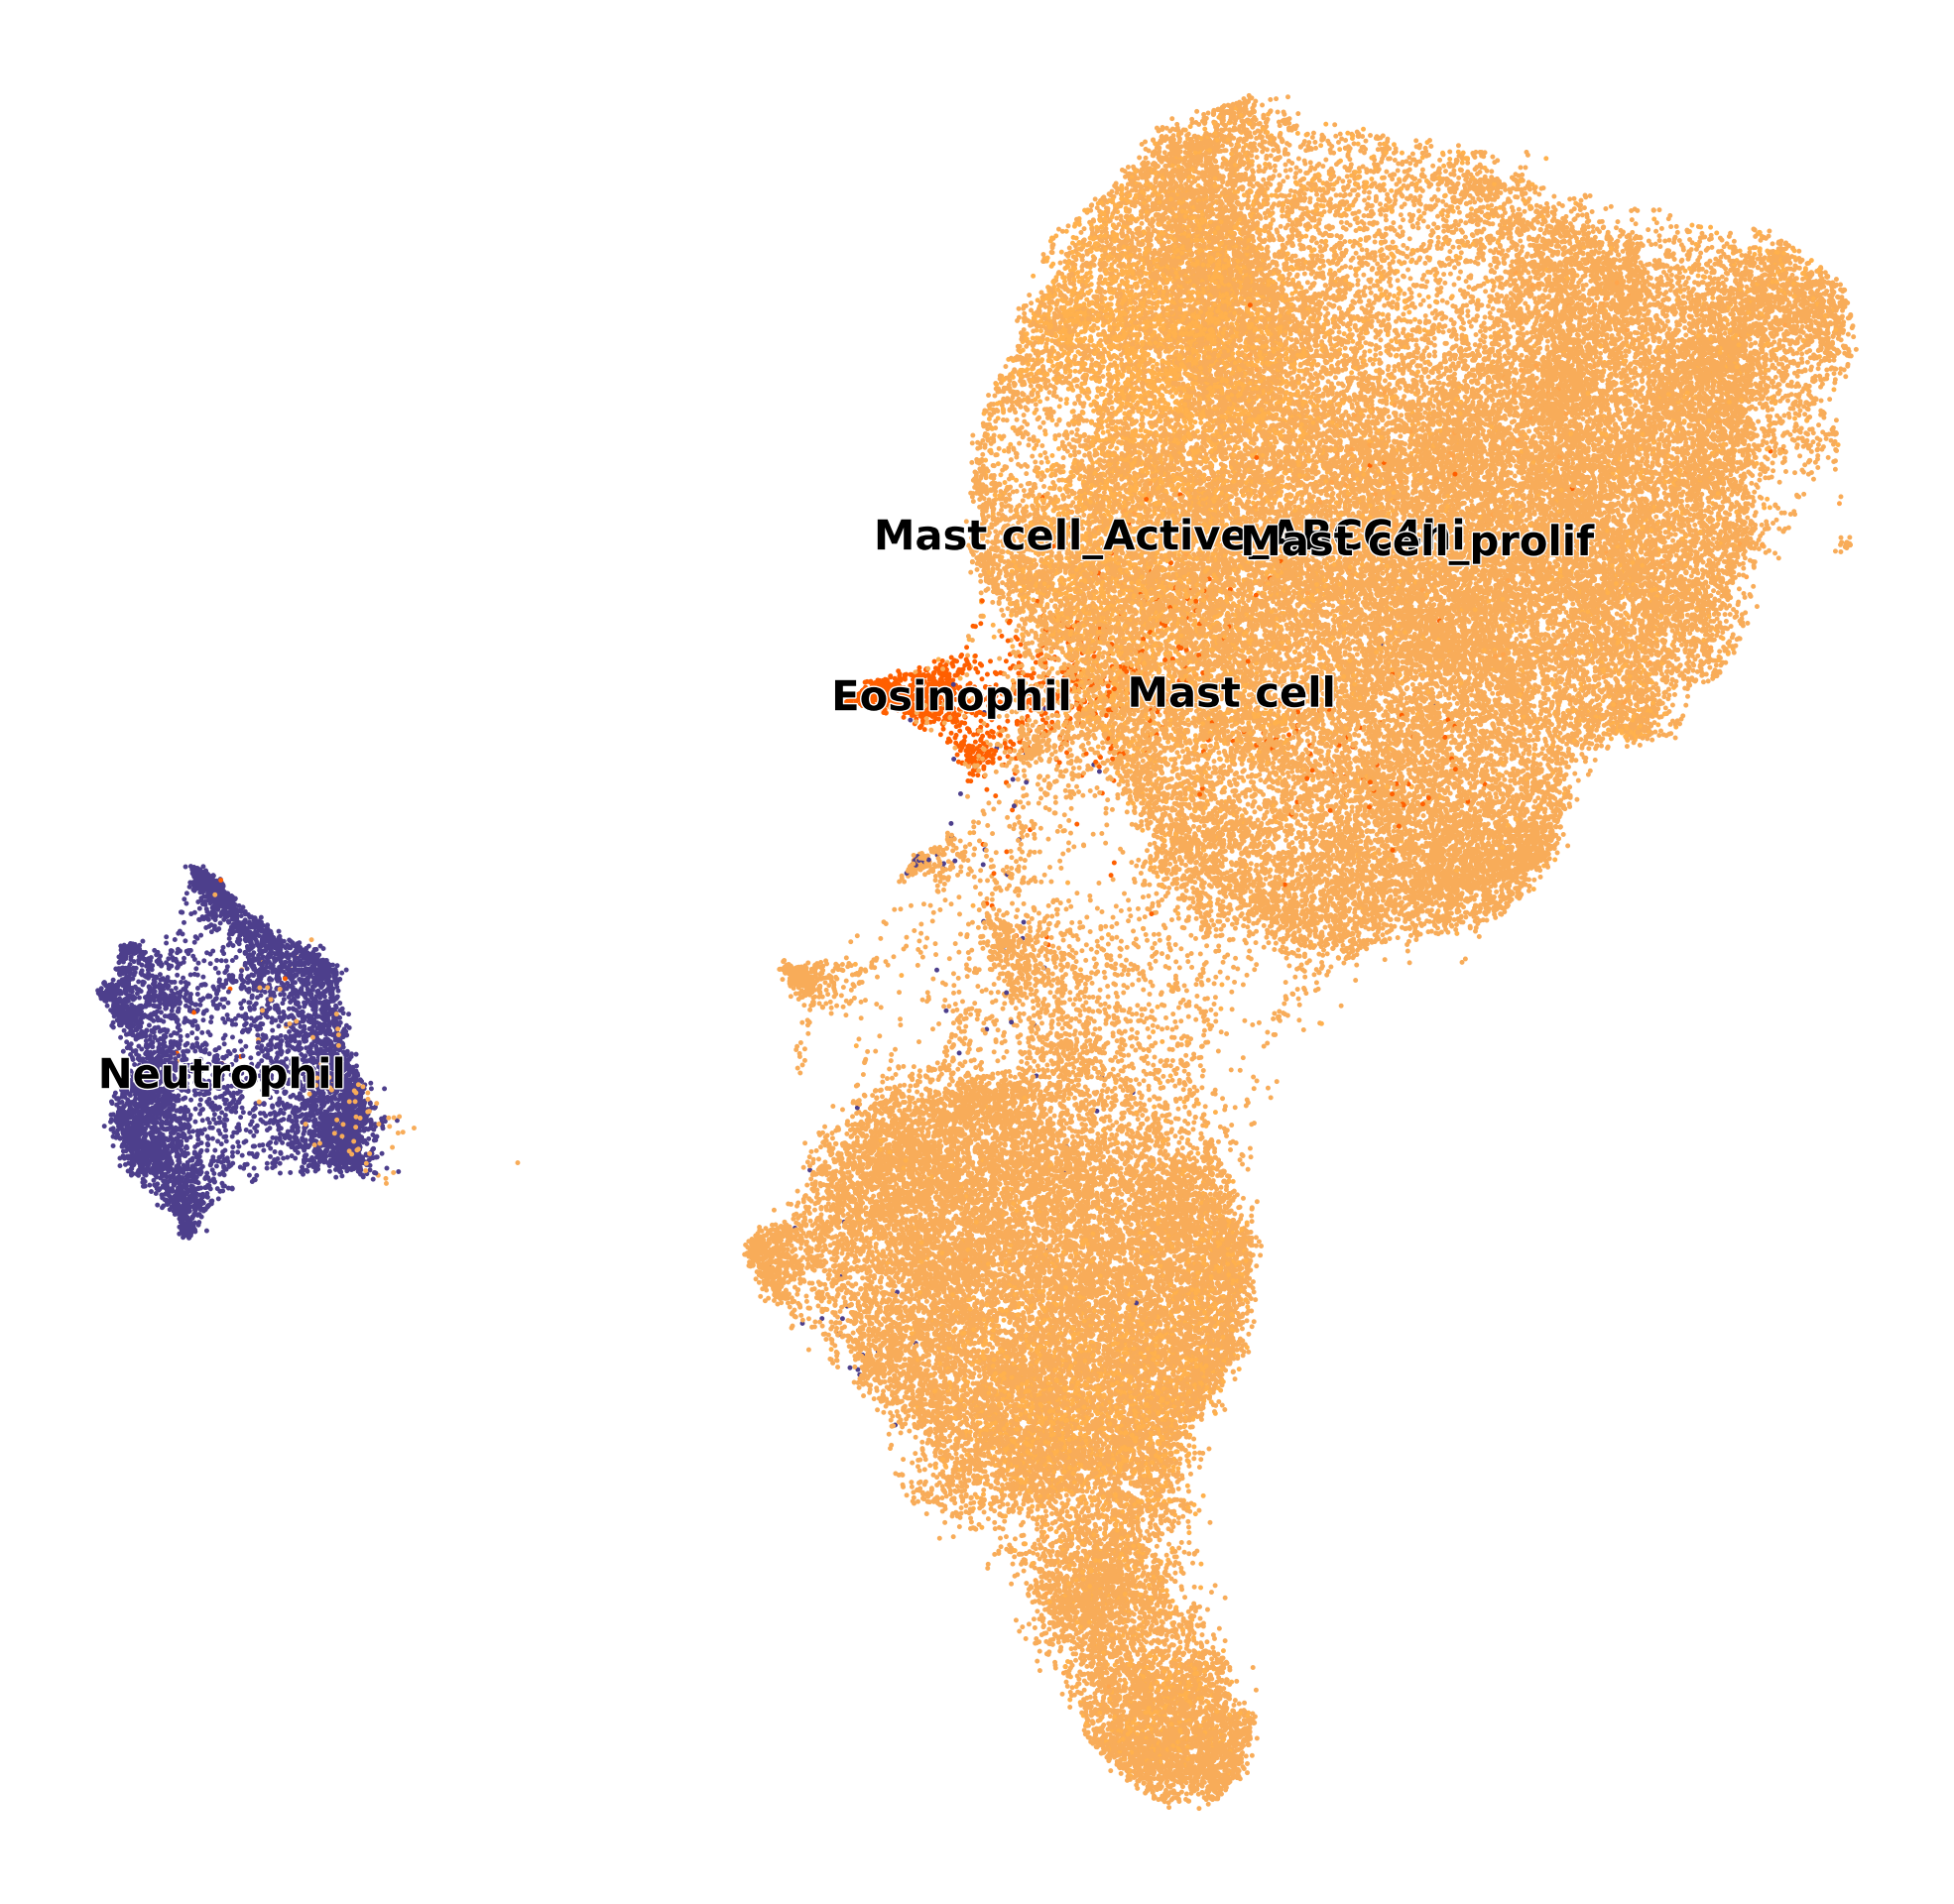

In [25]:
import pickle

try:
    file_path = "/nfs/team298/ls34/dicts/color_for_adult_skin2.pkl"
    with open/(file_path, "rb") as f:
        colors = pickle.load(f)
except:
    !wget "https://raw.githubusercontent.com/haniffalab/spatial_skin_atlas/main/misc/color_for_adult_skin2.pkl" \
         -O color_for_adult_skin2.pkl
    file_path = "./color_for_adult_skin2.pkl"
    with open(file_path, "rb") as f:
        colors = pickle.load(f)
colors= colors | {'New/unlabelled/excluded': "#C8C8C8",
                  'New/unlabelled/unspecific':  "#C8C8C8",
                  'F1: Superficial': '#ffef5a',
    'F2/3: Perivascular': '#364f99',
    'F2: Universal': '#91bae2',
    'F3: FRC-like': '#c6508f',
    'F4: DP_HHIP+': '#c9efb4',
    'F4: DS_DPEP1+': '#3d6f3b',
    'F4: TNN+COCH+': '#00f273',
    'F5: NGFR+': '#8981a7',
    'F5: RAMP1+': '#4b2657',
     'F6: Inflammatory myofibroblast': "#75fbfd",
     'F7: Myofibroblast': "#2f6565",
       'F8: Fascia-like myofibroblast':"#EFA093", #'#dd7465',
 'F_Fascia': "#00004D",
                     "Th2": "#2A6072",      # Dark Blue (classic, strong contrast)
    "Tfh-like": "#AAA9A9",  # Neon Blue (bright, electric tone)
    "Th17": "#FFB3B3",
                  "adipocyte": '#B8860B'

     #   "TRM_IL13+": "#7D93C7"
    
                               } 
print(f"Loaded {len(colors)} colour entries")
adata
colors2 = {'Sweat gland_clear': '#8AEAEA',
 'Sweat gland_dark': '#006D6D',

 'LE1': '#FFFF2B',

 'MacTREM2hi': '#E9E2F0',
 'LE2': '#D5D500',
 'Scar_VE/Peri': '#FF9B9B',
 'Mac2_MMP19hi': '#DDD3E9',
 'Mast cell_Active_ABCC4hi': '#FFB14D',
 'Mac2_HRH1+': '#D2C4E2',
 'KC3*': '#758BCC',
 'KC1/2_cycling': '#e0c5d2',
 'KC4/5': '#272c5f',
 'KC4*': '#9FC2CD',
 'KC_HFSC': '#D600FF',
 'T_CD4ex': '#FFE8B3',
            'ASIC2+ Mechanoreceptor': '#F1F1F1',
            'lowq': '#F1F1F1',
                       'new': '#F1F1F8',


 'ASIC2+ Mechanoreceptor2': '#F1F1F1',
 'Tfh-like2': '#AAA9A9',
 'ASIC1_4_KIF5C+': '#6F6F6F',
 'TRM_ex': '#FFF8E1',
 'Mast cell_prolif': '#FFA64D',
 'Th17/IFNGhi': '#FFA000',
 'Tc1_GIMAPhi': '#FFD06A',
 'KC_HF: ORS_KLK8+_SRGN+': '#E8FFF0',
 'ASIC2+ Mechanoreceptor1': '#D9D9D9',
 'Tfh-like1': '#AAB7C3',
 'Th_IFNGhi': '#FFB00A',
 'T DC Doublet': '#B38066',
 'SCC_KC': '#7B9299',
 'Melanoma': '#4E3323',
 'BCC+SCC_KC': '#576166',
 'Merkel_KC': '#FFE5E5'}
colors=colors|colors2
COLORS = {
    "ILC3+CCL1+PTGDS+": "#FF2F92",        # neon pink
    "ILC1_Prolif": "#FFD800",             # bright yellow
    "Tγδ": "#8B5A2B",                     # brown
    "CD4+_Prolif": "#C2B280",             # dark beige
    "CD4_IL13+ (was TRM_IL17+)": "#87CEEB",# sky blue
    "Th(ribosomal)": "#F2E6D8",            # very pale beige
    "Tc3_IFNGhi_CCL3+": "#E6D3B1",         # neon-ish beige
    "Tc1_BACH2+": "#E39A2E",               # orange beige
    "Th_PPARGhi_SLC10A1+TNFhi": "#9BB7D4", # bluish beige
    "Tc2_GZMH+": "#F28C28",                # orange
    "Tc3_IFNGhi_exhausted": "#FFE5C4",     # very pale orange
    "CD4_Tex_GZMK+IL10+PDCD1+": "#EFE2CF", # very pale beige
    "ILC3_Early": "#F6B7C6",               # pale pink
    "Th17_CCL20+ZBTB16+LAYN+": "#6FBF73",  # greenish
    "Th1_KLRG1+": "#D8C4A8",               # beige
    "Tc2_GZMH+TOX+": "#F3E6D3",             # very pale beige (distinct)
    "TRM_IL13+_2": "#3A6EA5",               # blue
    "Th1_KLRG1+GZMK+A2M+LYAR+": "#FFF2A6",  # pale yellow
    "Th17/Th1__IFNG+CXCL13+SOX5+": "#FFCC00", # bright yellow (distinct hue)
    "Th17_IL17F+": "#C23B22",               # reddish
    "ILC3_Prolif": "#B8A17D",               # dark beige
    "Tc1_BACH2+_TOXhi": "#9E8B6B",          # darker beige
    "TRM_exhausted": "#E6F0FA",             # very very pale blue
    "Th17_LAG3lo_IL23RhiBLK+": "#B22222",   # deep reddish
    "CD8+_naive": "#F5EDDF",                # very pale beige
    "TRM_IL13+_3_CD9+KRT7+": "#1E90FF",     # neon blue
    "TRM_IL13+_1": "#0B3C5D",               # dark blue
    "CD4 (was TRM_IL17+)": "#F9E1E1",       # very very pale red
    "Tfh-like1_ICA1+": "#9E9E9E",            # grey
    "CD4_IL17+ (was TRM_IL17+)": "#800020", # burgundy
    "TRM_CD4+_IL17+ITGA1+": "#F4A6A6",      # pastel red
    "TRM2_exhausted": "#EDF4FB",            # very pale blue (distinct)
    "TRM_CD4/CD8_mixed": "#A89272",         # dark beige
    "Th_PPARGhi_HLF+": "#8C7A5E",            # dark beige (darker)
    "CD8+_naive_exhausted_HAVCR2+": "#E8C2B3", # pinkish beige
    "Th2/mac": "#000000",                   # black
    
        "CD8+_Prolif": "#C2B280",          # dark beige
    "CD4_LOWQ(was TRM_IL17+)": "#D3D3D3",  # light grey
    "Th2_SLC10A1+TNFhi": "#7EC8E3",     # sky blue (clear, not pastel mush)
    "Th17_IL17A+IL17F+": "#4CAF50",     # grass green
    "Th17_IL17A+IL23R+": "#A5D6A7",     # pale green
    "T_Prolif_mixed": "#1B9E3C",        # intense green (distinct from Th17)
    "Th2_SATB1+PRDX2+": "#EEEEEE",      # very pale grey (still visible on white)
     "lowq_ithink": "#4D4D4D",
    "lowq_mac": "#595959",
    "Pericyte1doublet": "#666666",
    "Tlowq": "#737373",
    "KC2/lowqmaybe": "#808080",
    "KC2_lowq": "#8C8C8C",
    "lowq_ilc": "#999999",
    "ILC_Stress": "#A6A6A6",
    "Mac_Prolif": "#B3B3B3",
    "Tfh-like_Ex": "#BFBFBF",
    "Th1_IFNG+": "#CCCCCC",
    "Th17_ZBTB16+": "#D9D9D9",
    "Tc0 i think": "#E6E6E6",
    "KC_HF: ORS_CLEC2A+KLK8+": "#F0F0F0",
    
    
    
}
colors=colors|COLORS


sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(25,25))



sc.pl.umap(
    adata,
    color='final17',
    show=True,
    frameon=False,
    legend_loc= "on data",
    legend_fontsize=30,
    s=50,
    title='',
    legend_fontoutline=2,
    vmax=60,
    palette=colors,
                   
   # save="supplementary_integration.pdf"
)



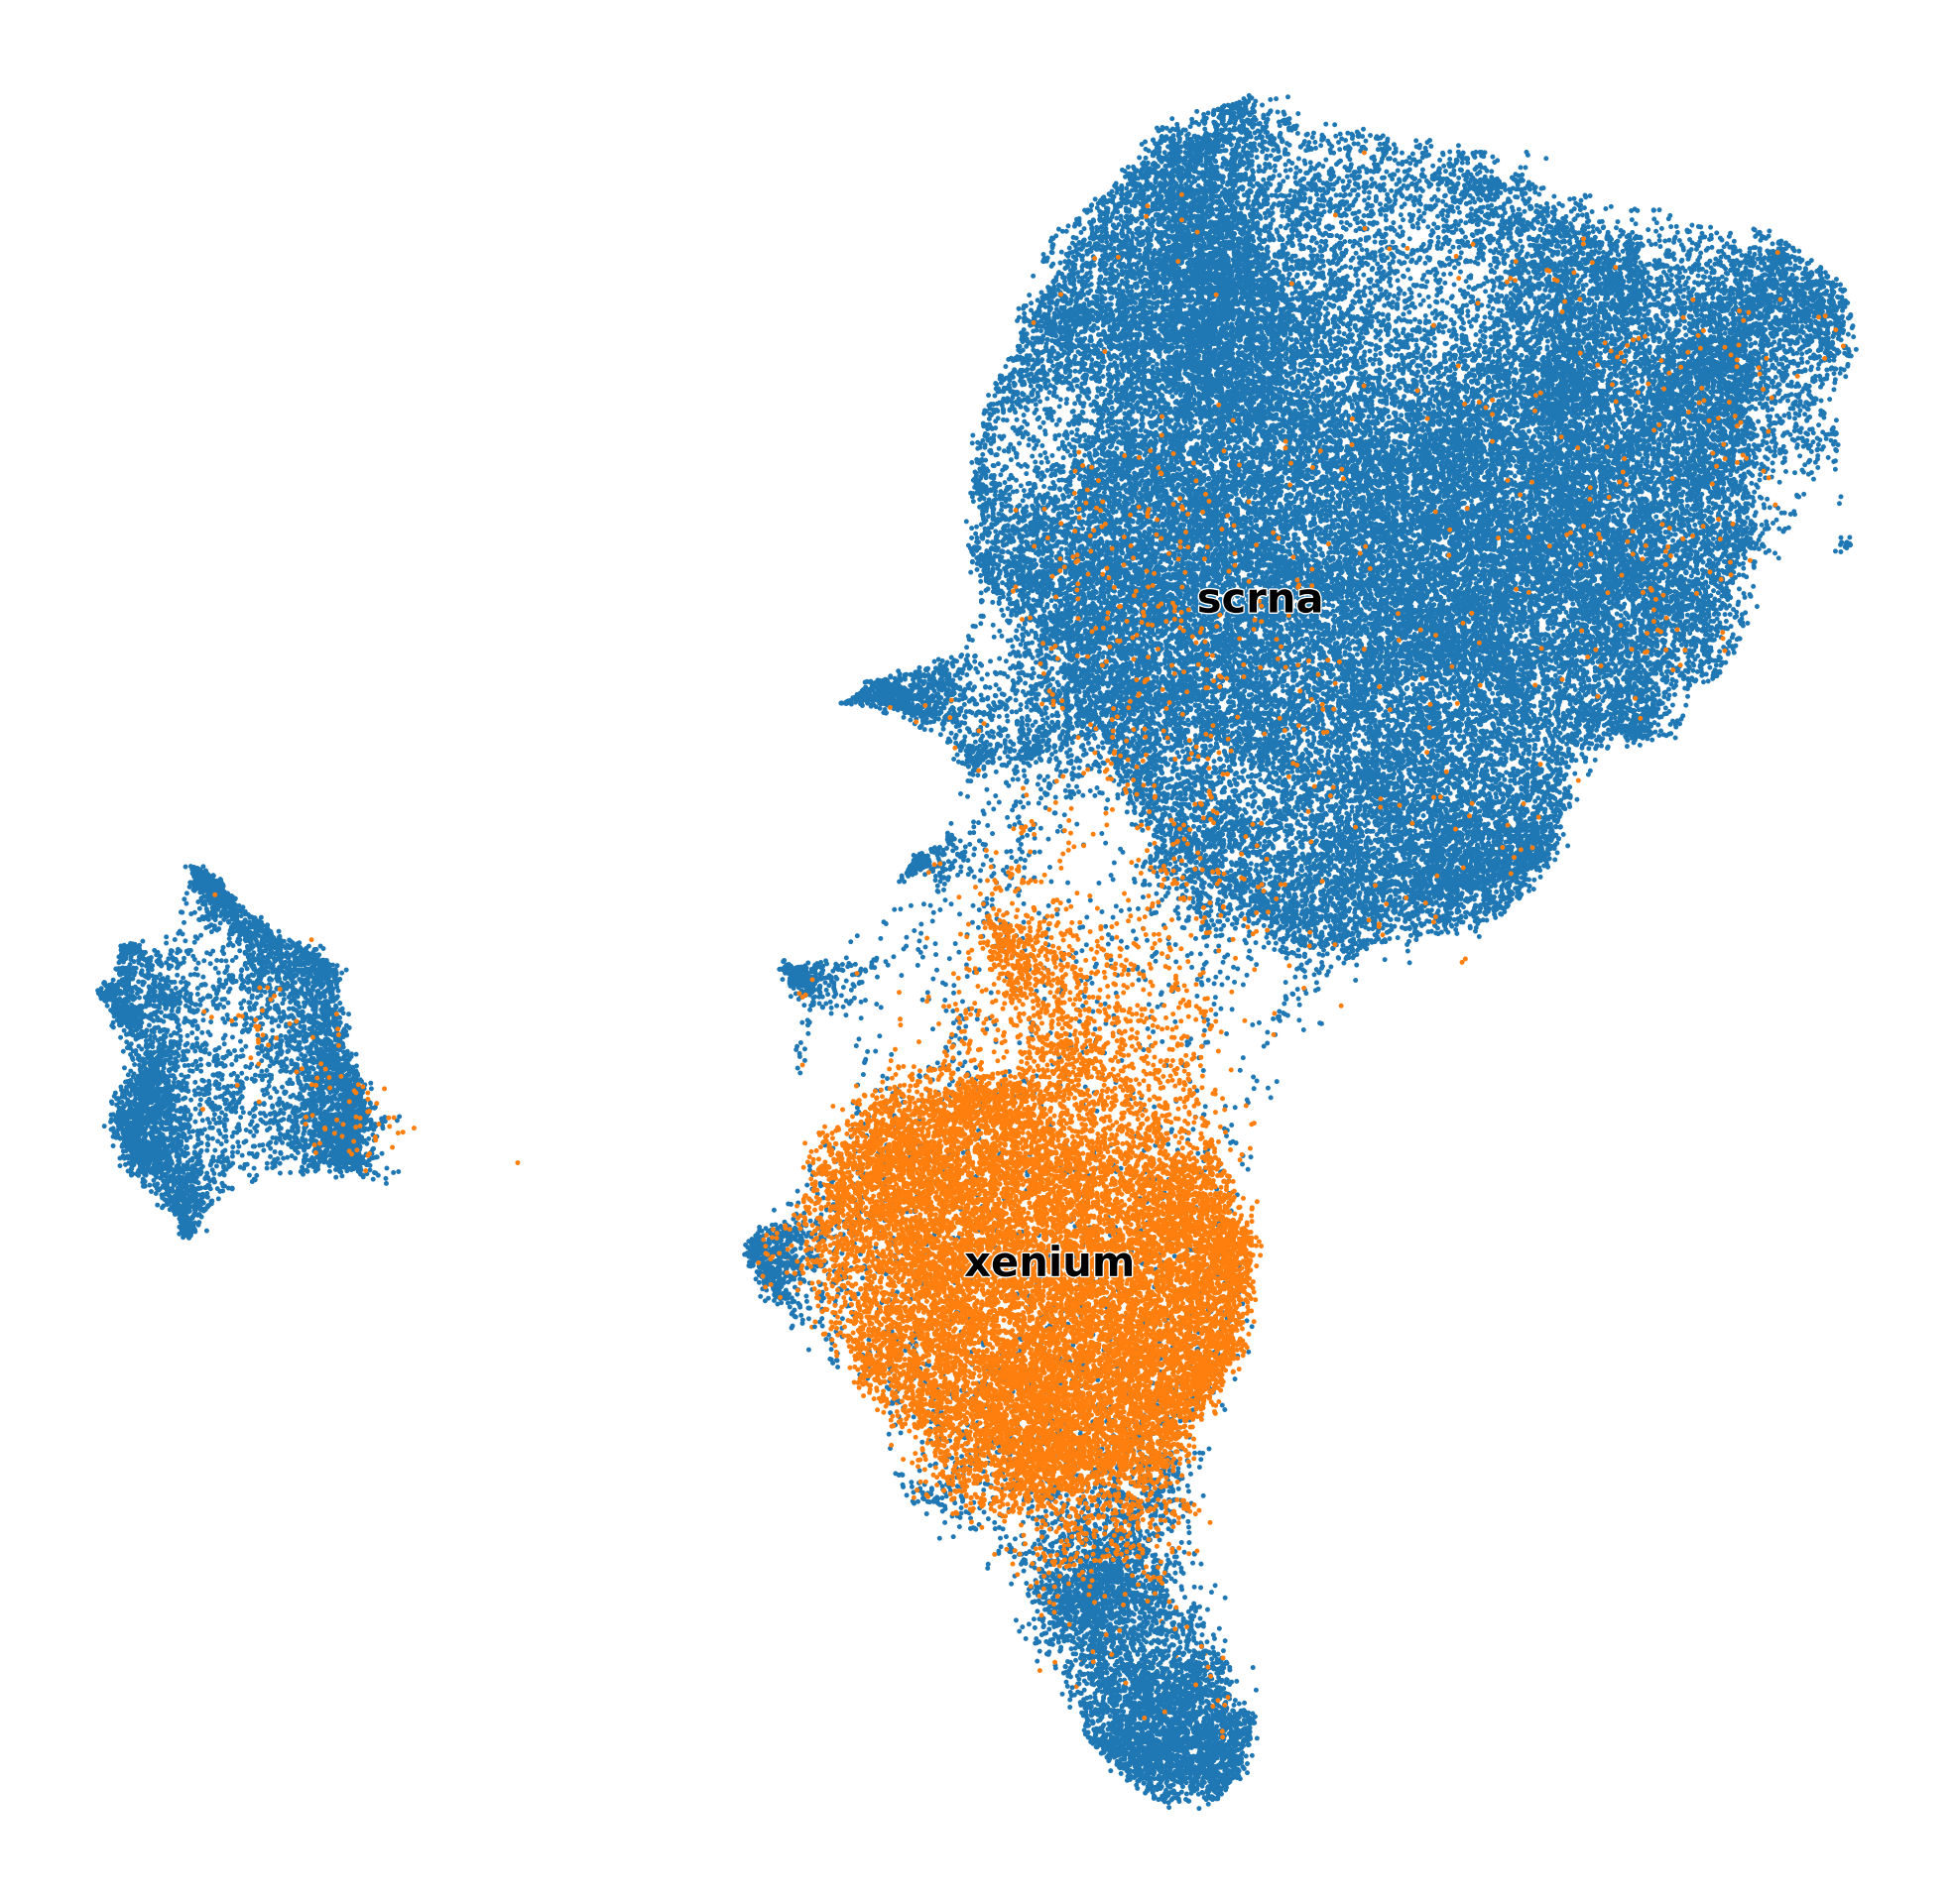

In [26]:
sc.pl.umap(
    adata,
    color='tech',
    show=True,
    frameon=False,
    legend_loc= "on data",
    legend_fontsize=30,
    s=50,
    title='',
    legend_fontoutline=2,
    vmax=60,
                   
   # save="supplementary_integration.pdf"
)



/tmp/ipykernel_3629100/929246302.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.3, key_added='leiden_res0.3', neighbors_key="neighbor_20")


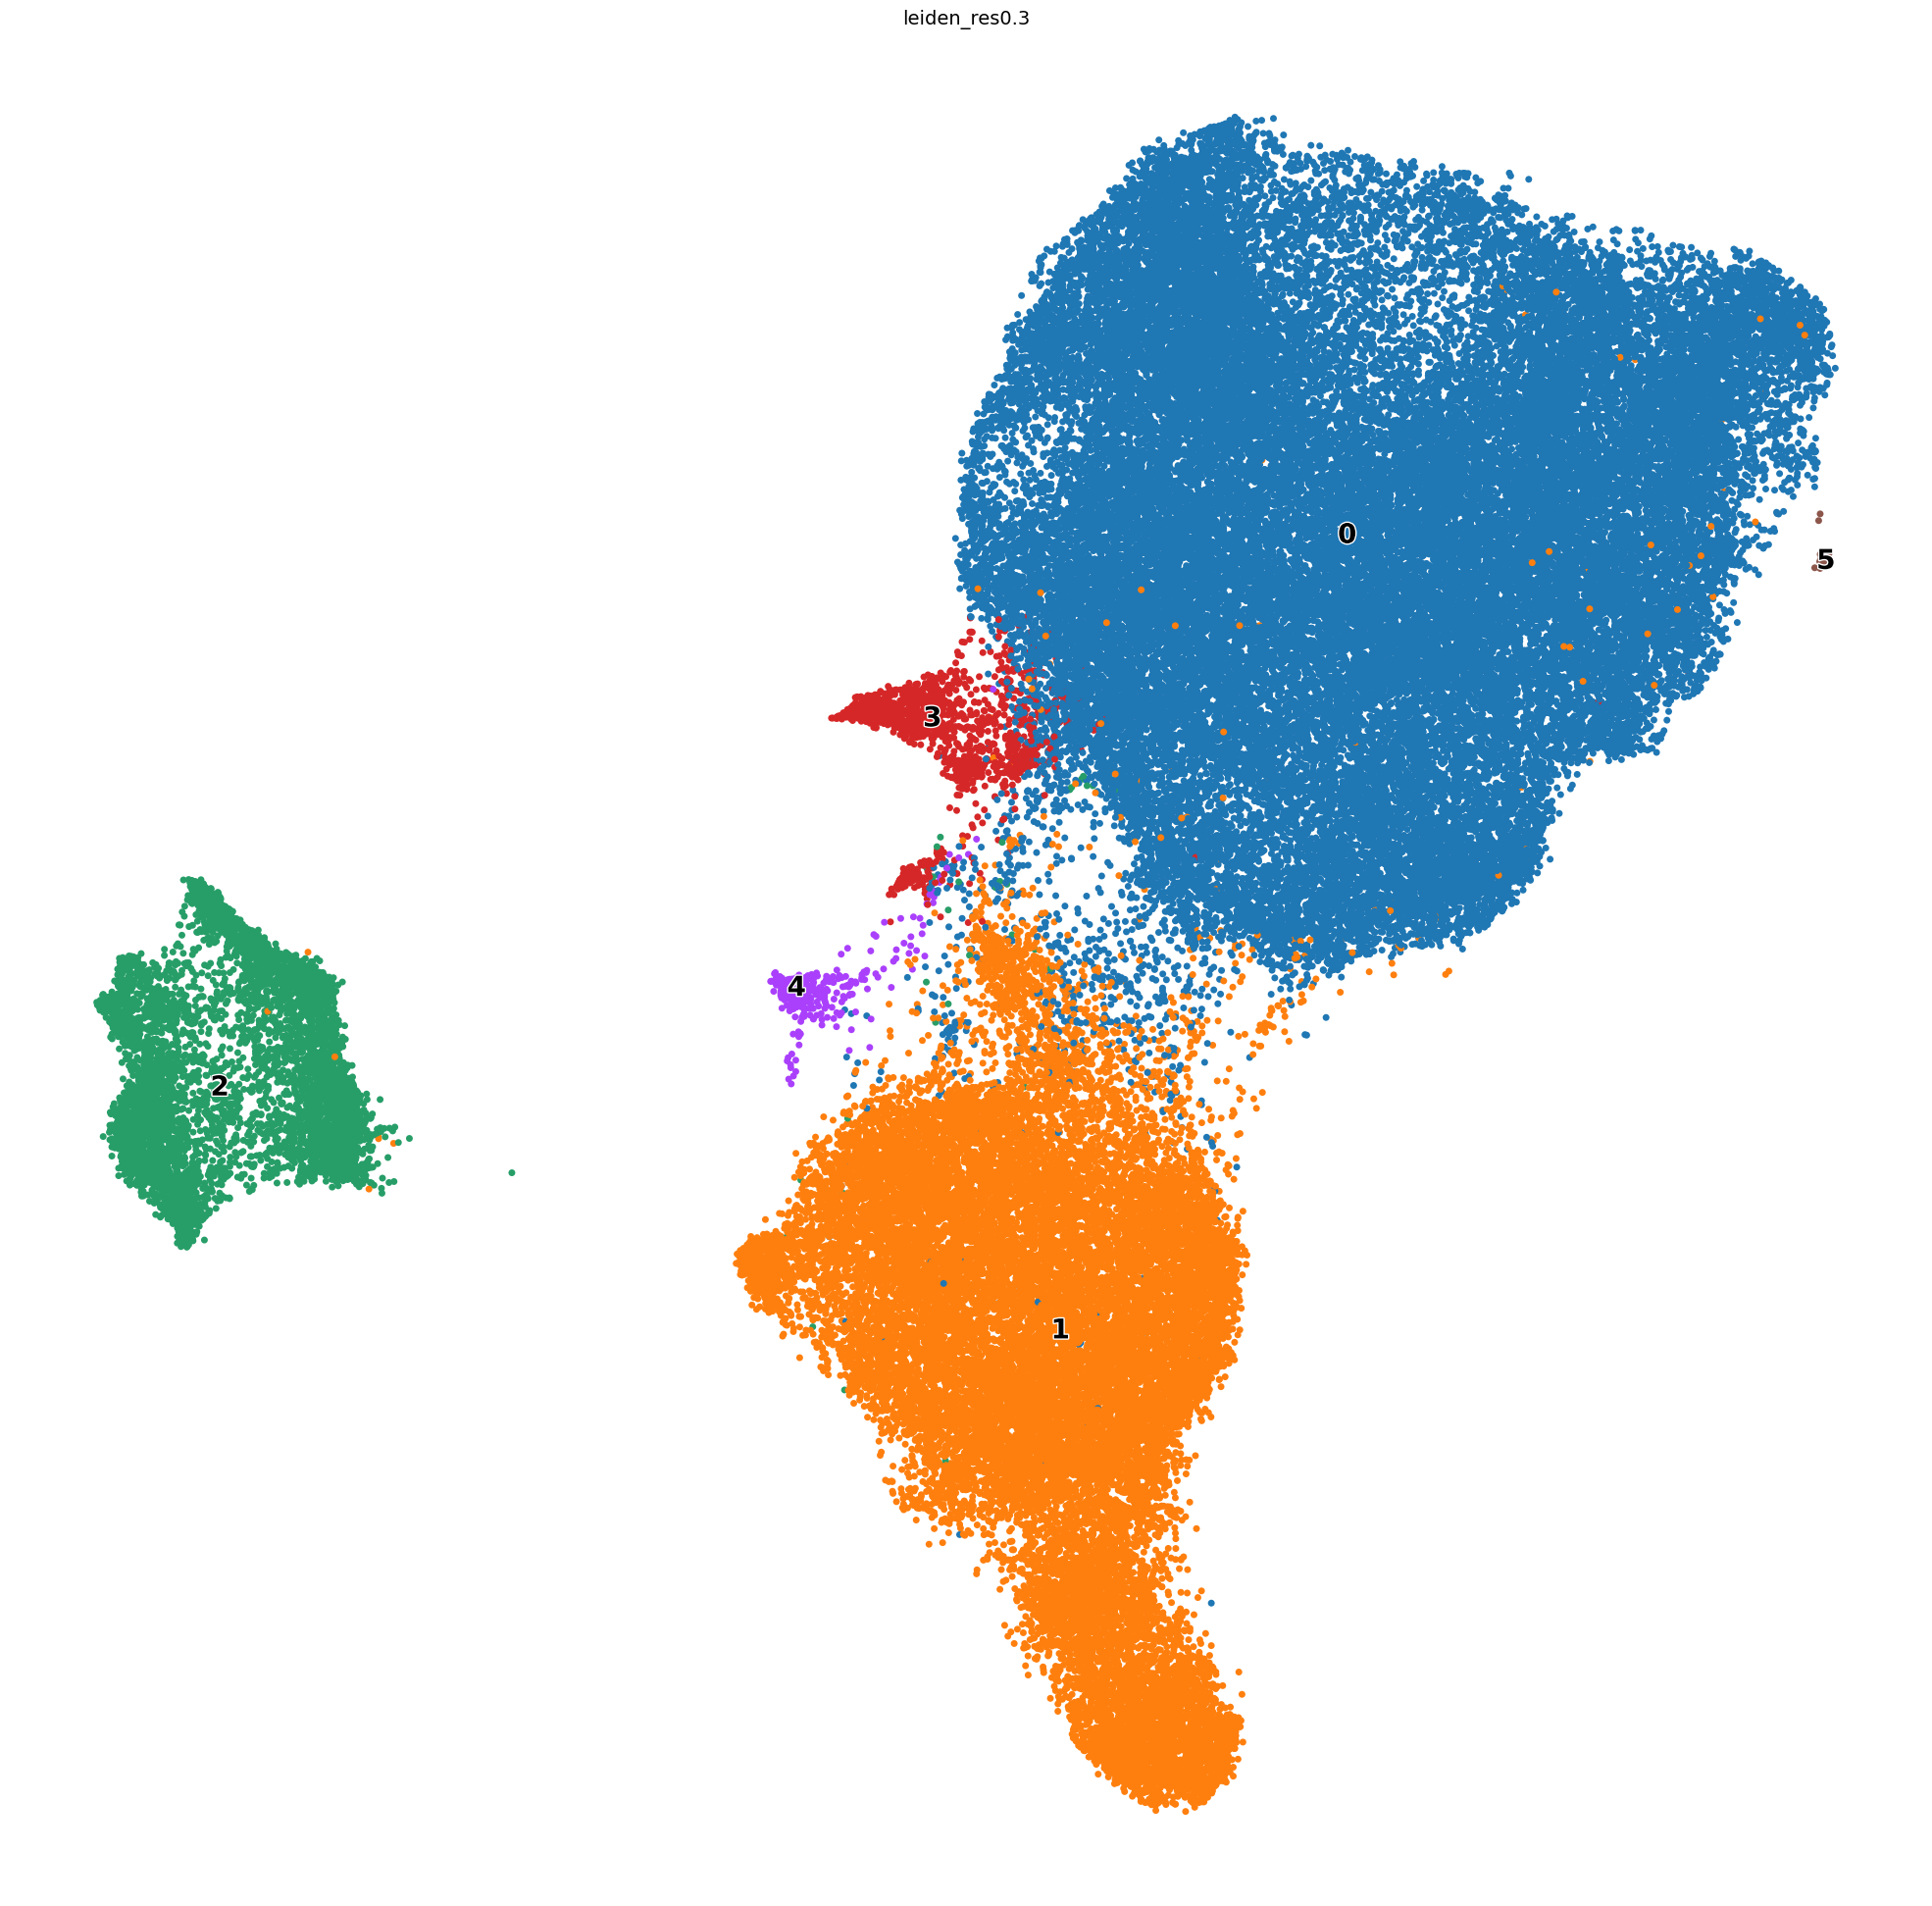

In [27]:
#sc.tl.leiden(adata, resolution=0.3, key_added='leiden_res0.3', neighbors_key="neighbor_20")

sc.pl.umap(
    adata,
    color=[
      'leiden_res0.3',
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20
)

In [35]:
RENAME = {'0': 'Mast cell',
 '1': 'Mast cell',
 '2': 'Neutrophil',
 '3': 'Eosinophil',
 '4': 'Mast cell',
 '5': 'Mast cell',
 # '6': 'Mast cell',
 # '7': 'Mast cell',
 # '8': 'Eosinophil'
         }

adata.obs["tmp"]=adata.obs["leiden_res0.3"].map(RENAME)

In [29]:
{x:x for x in sorted(adata.obs["leiden_res0.3"].unique())}

{'0': '0', '1': '1', '2': '2', '3': '3', '4': '4', '5': '5'}

In [30]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)



/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


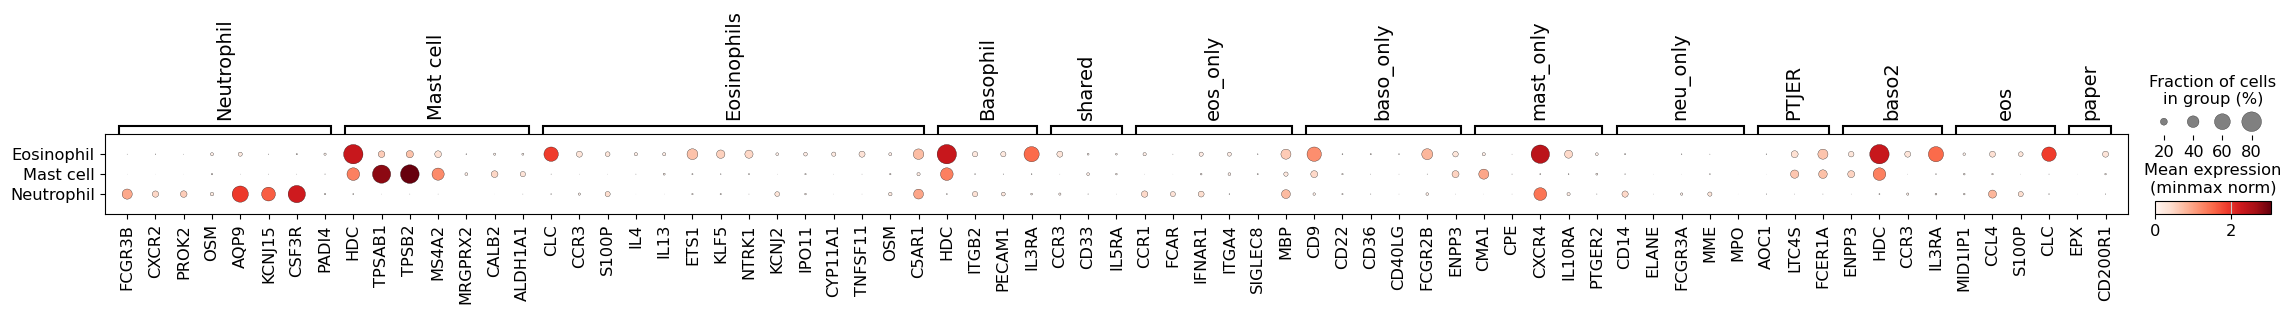

/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


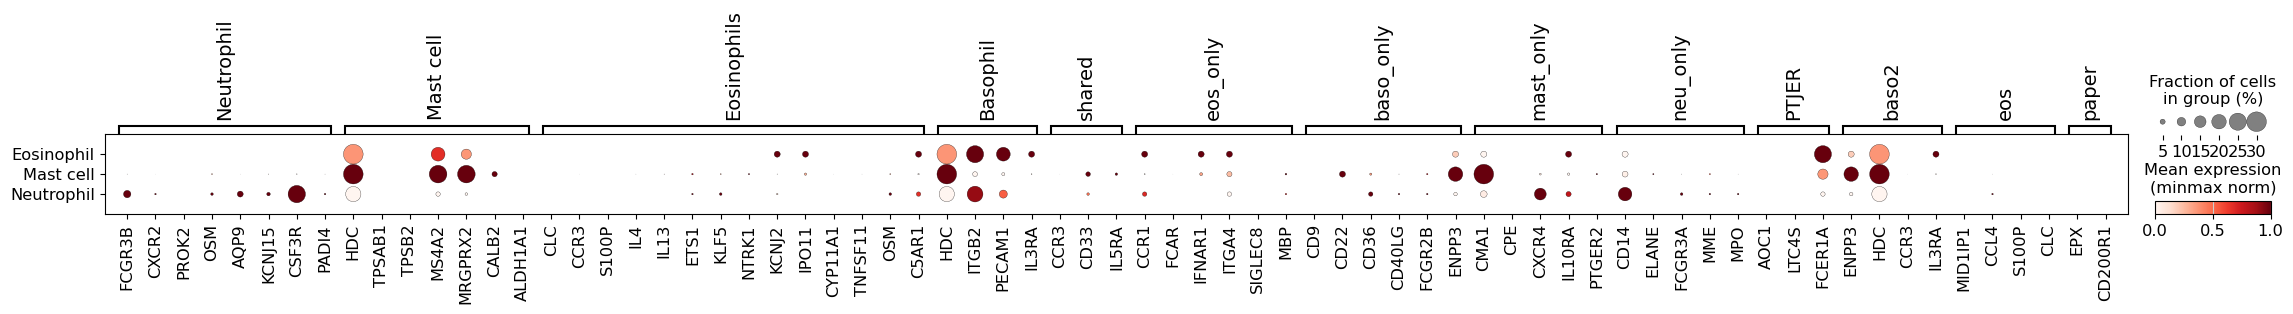

In [36]:
PLOT = { 'Neutrophil': [#'CXCL8',
     'FCGR3B', "CXCR2", "PROK2", "OSM",  #KCNJ15, ADGRG3
        "AQP9",
    "KCNJ15",
 
    #"CXCL12",
    #"LILRB4",
    #"SLIT3",
    "CSF3R",
    #"TNFSF13B",
   # "TNFSF10",
    "PADI4",
                # "MPO"
               ], 
                      #(adata.obs[CATEGORY]== "Neutrophil")]
              "Mast cell": [#"HPGDS", "KIT", "HPGD",
                    "HDC", #"GATA2",   
                    "TPSAB1", "TPSB2", "MS4A2","MRGPRX2",
                              "CALB2", "ALDH1A1" #"CAVIN2", "HEY1"
                ],
            "Eosinophils": [ "CLC", "CCR3",#"CCL23",    #"PTGDR2", "P2RY1", 
                            "S100P",
                             "IL4",
    "IL13",
    "ETS1",
    "KLF5",
    "NTRK1",
    "KCNJ2",
    "IPO11",
    "CYP11A1",
    "TNFSF11",
    "OSM", "C5AR1"
                           ],
        "Basophil": [#"MCPT8", 
            "HDC",
                    "ITGB2", "PECAM1", "IL3RA"
                    ],
           "shared": ["CCR3", "CD33", "IL5RA"],
    "eos_only": ["CCR1", "FCAR", "IFNAR1", "ITGA4", "SIGLEC8", "MBP"],
    "baso_only": ["CD9", "CD22", "CD36", "CD40LG", "FCGR2B",
                 "ENPP3"
                 ],
    "mast_only": ["CMA1", "CPE", "CXCR4", "IL10RA", "PTGER2"],
    "neu_only": ["CD14", "ELANE", "FCGR3A", "MME", "MPO"],
    "PTJER": ["AOC1", "LTC4S", "FCER1A"],
      "baso2": ["ENPP3", "HDC", "CCR3", "IL3RA"],
        "eos":  ["MID1IP1", "CCL4", "S100P", "CLC",],
        "paper": ["EPX",  "CD200R1"]
            }
sc.pl.dotplot(adata[adata.obs["tech"]!="xenium"],#[adata.obs["Site_status"]=="Lesional"], 
              PLOT,
              groupby="tmp",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )
sc.pl.dotplot(adata[adata.obs["tech"]=="xenium"],#[adata.obs["Site_status"]=="Lesional"], 
              PLOT,
              groupby="tmp",
              dendrogram=False, 
                standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
                dot_max=.3,
             )
 

In [32]:
adata[adata.obs["tech"]=="xenium"].obs.dataset_id.value_counts()

dataset_id
nan    18604
Name: count, dtype: int64

In [33]:
adata[adata.obs["tech"]=="xenium"].obs.Patient_status.value_counts()

Patient_status
AD                       6761
nan                      3634
Psoriasis                2793
3d_Lesional_baseline     2057
3d_Week12                1076
mintflowrevision_todo     789
Healthy                   785
HS                        709
Name: count, dtype: int64

In [37]:
CATEGORY="tmp"

sc.tl.rank_genes_groups(adata, CATEGORY, method='wilcoxon', key_added="de_leiden");
df22 = pd.DataFrame(adata.uns['de_leiden']['names'])
for i,x in enumerate(df22.columns):
    print(i, x)
                                       
   

0 Eosinophil
1 Mast cell
2 Neutrophil


Eosinophil


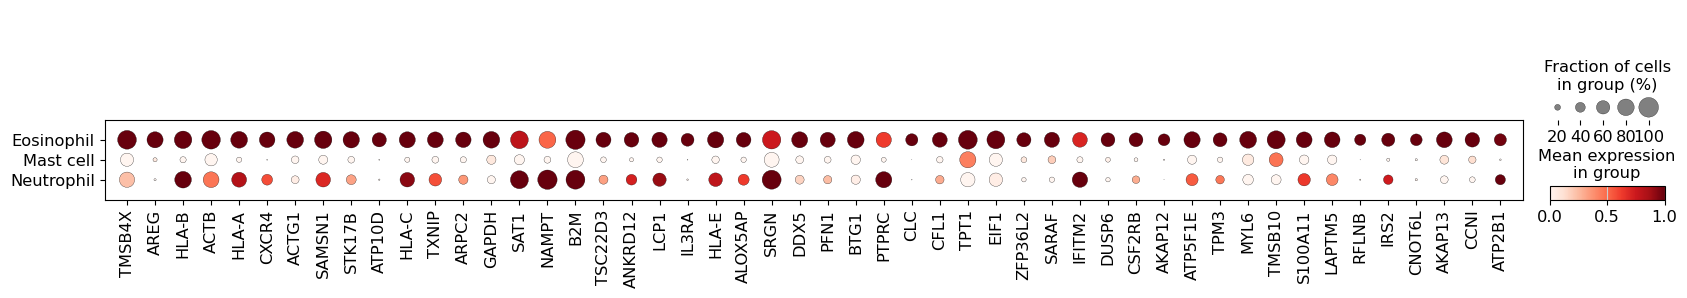

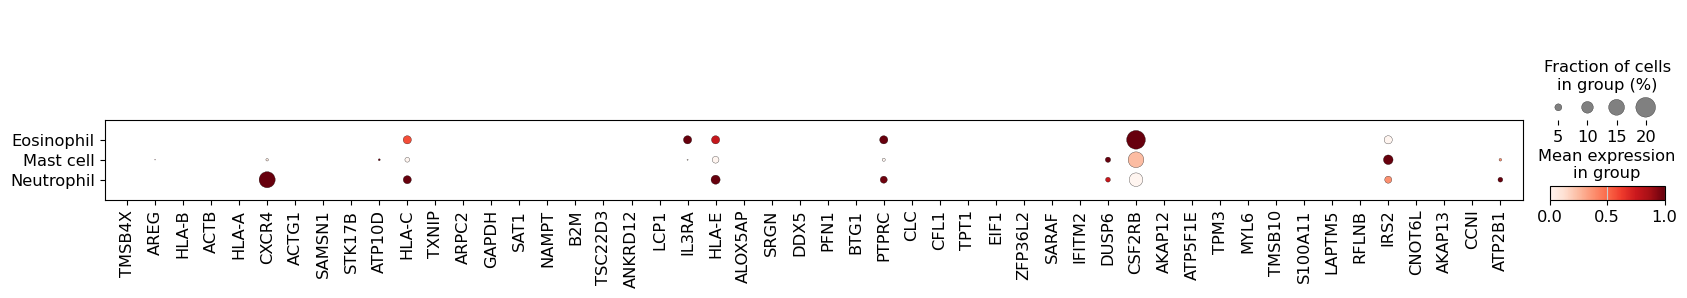

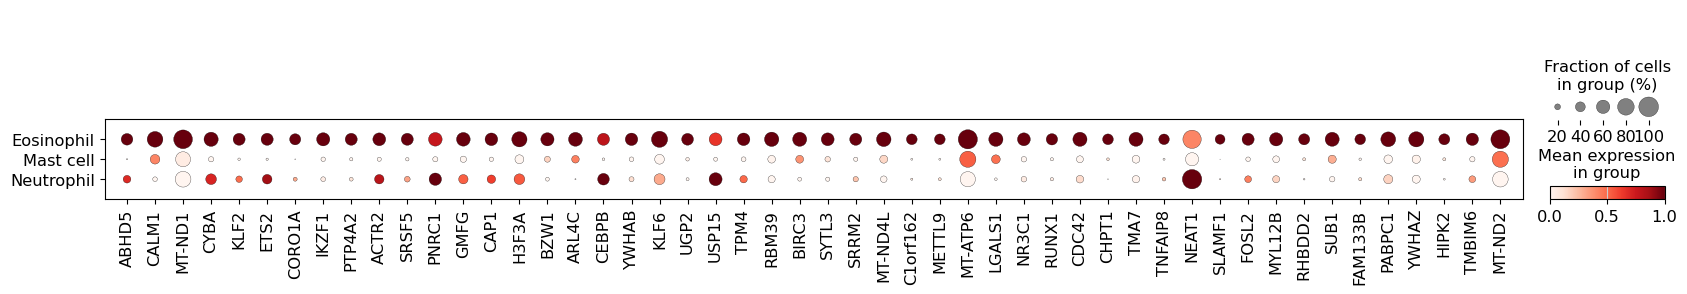

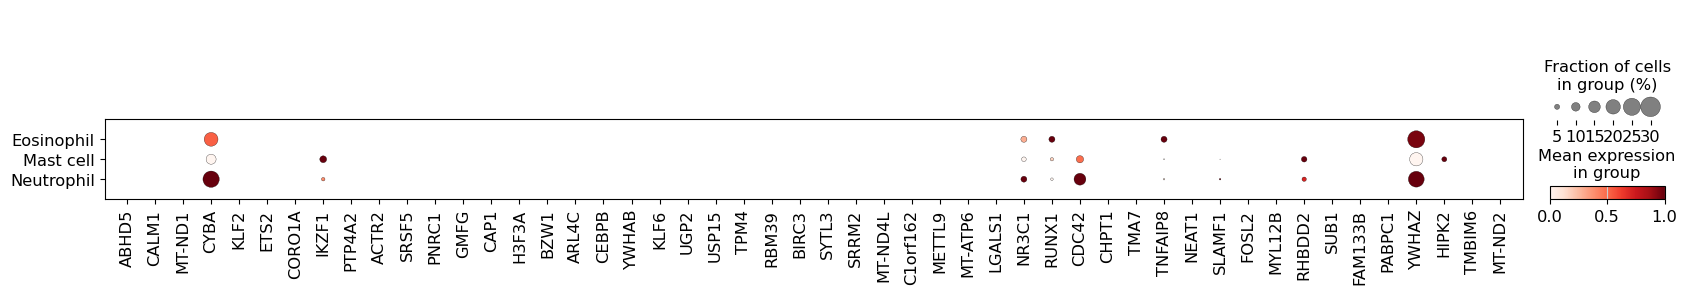

In [39]:
select_population = list(df22.columns)[0]
print(select_population)
genes0 = df22[select_population][:50]
genes1 = df22[select_population][50:100]
genes2 = df22[select_population][100:150]
genes3 = df22[select_population][150:200]


sc.pl.dotplot(
    adata[adata.obs["tech"]!="xenium"],
    genes0,
    groupby=CATEGORY,
    standard_scale="var",
    dendrogram=False, 
)
sc.pl.dotplot(
    adata[adata.obs["tech"]=="xenium"],
    genes0,
    groupby=CATEGORY,
    standard_scale="var",
    dendrogram=False, 
)
sc.pl.dotplot(
    adata[adata.obs["tech"]!="xenium"],
    genes1,
    groupby=CATEGORY,
   standard_scale="var",
    dendrogram=False, 
) 
sc.pl.dotplot(
    adata[adata.obs["tech"]=="xenium"],
    genes1,
    groupby=CATEGORY,
   standard_scale="var",
    dendrogram=False, 
) 


In [40]:
adata_xenium = adata[adata.obs["tech"]=="xenium"].copy()
adata_xenium[adata_xenium.obs[CATEGORY]=="Eosinophil"].obs.info_id6.value_counts()


 

 

info_id6
BK30_Day 14                                                      2
nan                                                              2
3D_BK22_Lesional_baseline-D2                                     1
3D_BK25_week12-A1                                                1
BK23_Lesional Baseline                                           1
BK27_Day 3                                                       1
BK30_Day 3                                                       1
BK39_Non-lesional Baseline                                       1
BK39_Week 12                                                     1
BK51_Past Lesional                                               1
BK51_wk8 Relapse                                                 1
Lesional_CE3-SKI-24-FO-1-S22-A1                                  1
output-XETG00495__0068445__13871-JF-1_ROI-2__20250821__165859    1
output-XETG00495__0068445__13871-JF-1_ROI-7__20250821__165859    1
Name: count, dtype: int64

In [44]:

adata_eos = adata_xenium[adata_xenium.obs[CATEGORY]=="Eosinophil"]
adata_eos[adata_eos.obs["info_id6"]=="BK23_Lesional Baseline"].obs


,sample_id,barcode,GSE,Site_status,Patient_status,Location,Age,Sex,n_genes,dataset_id,...,final11,final12,final13,final14,final15,final16,final17,Annotation8,xeniummap,leiden_res0.3
gdipefkh-1_output-XETG00272__0041416__BK23-SKI-27-FO-1-S6-C2__20241107__113553,BK23_Lesional Baseline,nan,nan,Lesional,AD,nan,nan,nan,nan,nan,...,Mast cell,Mast cell,Mast cell,Mast cell,Mast cell,Mast cell,Mast cell,Mast cell,new,3


In [42]:
adata_eos = adata_xenium[adata_xenium.obs[CATEGORY]=="Eosinophil"]
adata_eos[adata_eos.obs["info_id6"]=="3D_BK22_Lesional_baseline-D2"].obs


,sample_id,barcode,GSE,Site_status,Patient_status,Location,Age,Sex,n_genes,dataset_id,...,final11,final12,final13,final14,final15,final16,final17,Annotation8,xeniummap,leiden_res0.3
appiclgd-1_output-XETG00055__0056853__BK22-SKI-27-FO-1-S57-D2__20250710__124204,3D_BK22_Lesional_baseline-D2,nan,nan,3D_Lesional_baseline,3d_Lesional_baseline,nan,nan,nan,nan,nan,...,Mast cell,Mast cell,Mast cell,Mast cell,Mast cell,Mast cell,Mast cell,Mast cell,new,3


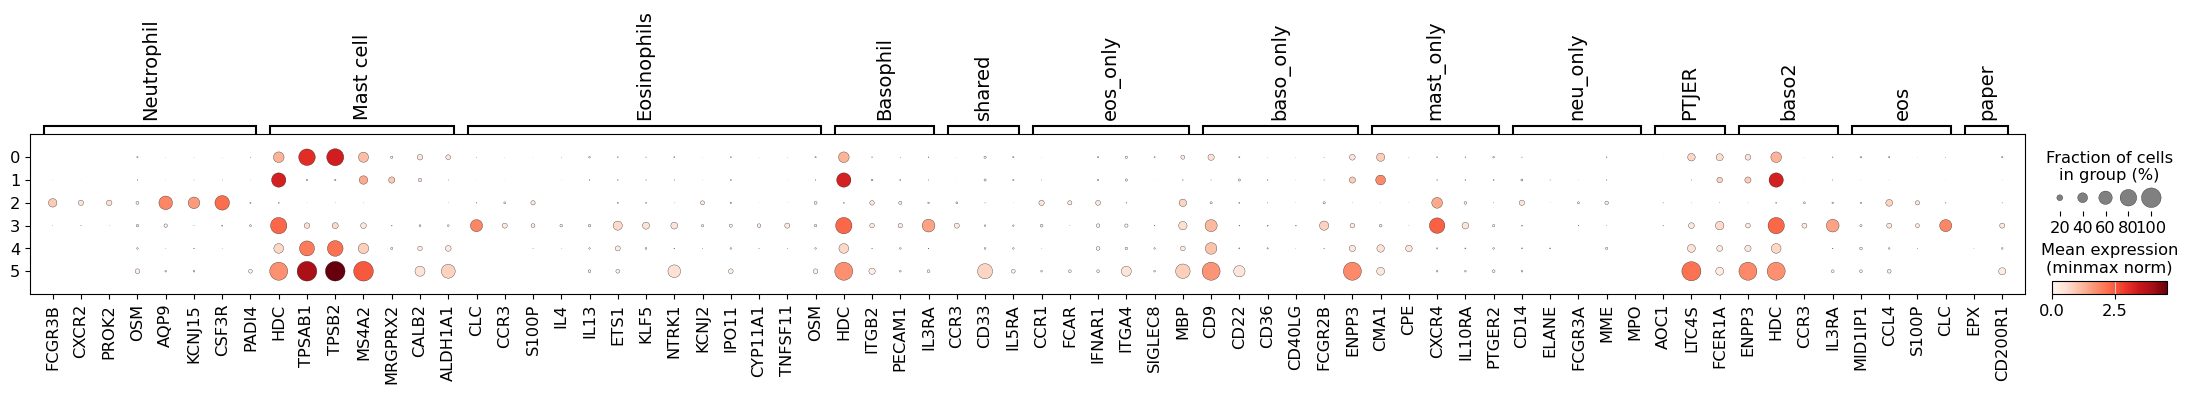

In [43]:
PLOT = { 'Neutrophil': [#'CXCL8',
     'FCGR3B', "CXCR2", "PROK2", "OSM",  #KCNJ15, ADGRG3
        "AQP9",
    "KCNJ15",
 
    #"CXCL12",
    #"LILRB4",
    #"SLIT3",
    "CSF3R",
    #"TNFSF13B",
   # "TNFSF10",
    "PADI4",
                # "MPO"
               ], 
                      #(adata.obs[CATEGORY]== "Neutrophil")]
              "Mast cell": [#"HPGDS", "KIT", "HPGD",
                    "HDC", #"GATA2",   
                    "TPSAB1", "TPSB2", "MS4A2","MRGPRX2",
                              "CALB2", "ALDH1A1" #"CAVIN2", "HEY1"
                ],
            "Eosinophils": [ "CLC", "CCR3",#"CCL23",    #"PTGDR2", "P2RY1", 
                            "S100P",
                             "IL4",
    "IL13",
    "ETS1",
    "KLF5",
    "NTRK1",
    "KCNJ2",
    "IPO11",
    "CYP11A1",
    "TNFSF11",
    "OSM"
                           ],
        "Basophil": [#"MCPT8", 
            "HDC",
                    "ITGB2", "PECAM1", "IL3RA"
                    ],
           "shared": ["CCR3", "CD33", "IL5RA"],
    "eos_only": ["CCR1", "FCAR", "IFNAR1", "ITGA4", "SIGLEC8", "MBP"],
    "baso_only": ["CD9", "CD22", "CD36", "CD40LG", "FCGR2B",
                 "ENPP3"
                 ],
    "mast_only": ["CMA1", "CPE", "CXCR4", "IL10RA", "PTGER2"],
    "neu_only": ["CD14", "ELANE", "FCGR3A", "MME", "MPO"],
    "PTJER": ["AOC1", "LTC4S", "FCER1A"],
      "baso2": ["ENPP3", "HDC", "CCR3", "IL3RA"],
        "eos":  ["MID1IP1", "CCL4", "S100P", "CLC",],
        "paper": ["EPX",  "CD200R1"]
            }



sc.pl.dotplot(adata,#[adata.obs["Site_status"]=="Lesional"], 
              PLOT,
              groupby="leiden_res0.3",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )

 

In [ ]:
STOP

In [ ]:
PLOT = { 'Neutrophil': [#'CXCL8',
     'FCGR3B', "CXCR2", "PROK2", "OSM",  #KCNJ15, ADGRG3
        "AQP9",
    "KCNJ15",
 
    #"CXCL12",
    #"LILRB4",
    #"SLIT3",
    "CSF3R",
    #"TNFSF13B",
   # "TNFSF10",
    "PADI4",
                # "MPO"
               ], 
                      #(adata.obs[CATEGORY]== "Neutrophil")]
              "Mast cell": [#"HPGDS", "KIT", "HPGD",
                    "HDC", #"GATA2",   
                    "TPSAB1", "TPSB2", "MS4A2","MRGPRX2",
                              "CALB2", "ALDH1A1" #"CAVIN2", "HEY1"
                ],
            "Eosinophils": [ "CLC", "CCR3",#"CCL23",    #"PTGDR2", "P2RY1", 
                            "S100P",
                             "IL4",
    "IL13",
    "ETS1",
    "KLF5",
    "NTRK1",
    "KCNJ2",
    "IPO11",
    "CYP11A1",
    "TNFSF11",
    "OSM"
                           ],
        "Basophil": [#"MCPT8", 
            "HDC",
                    "ITGB2", "PECAM1", "IL3RA"
                    ],
           "shared": ["CCR3", "CD33", "IL5RA"],
    "eos_only": ["CCR1", "FCAR", "IFNAR1", "ITGA4", "SIGLEC8", "MBP"],
    "baso_only": ["CD9", "CD22", "CD36", "CD40LG", "FCGR2B",
                 "ENPP3"
                 ],
    "mast_only": ["CMA1", "CPE", "CXCR4", "IL10RA", "PTGER2"],
    "neu_only": ["CD14", "ELANE", "FCGR3A", "MME", "MPO"],
    "PTJER": ["AOC1", "LTC4S", "FCER1A"],
      "baso2": ["ENPP3", "HDC", "CCR3", "IL3RA"],
        "eos":  ["MID1IP1", "CCL4", "S100P", "CLC",],
        "paper": ["EPX",  "CD200R1"]
            }
sc.pl.dotplot(adata[adata.obs["tech"]=="scrna",#[adata.obs["Site_status"]=="Lesional"], 
              PLOT,
              groupby="lvl5_annotation",
              dendrogram=False, 
               # standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
             # swap_axes=True,
             #   dot_max=.3,
             )

 

In [ ]:
sc.pl.umap(
    adata,
    color=[
        'final17',  
    ],
    legend_loc="on data",
    s=5, 
    legend_fontoutline=2,
    legend_fontsize=10,
    palette=colors|{"new": "#000000",
                    'TRM_IL13+/KC': "#000000",
                    'TRM_ITGA1+PDCD1+' : "#222222",
                     "T_lowcounts": "#E0E0E0",
    "CD8+_lowcounts": "#D6D6D6",
    "T_CD4+_lowcounts": "#CCCCCC",
    "CD4+_lowcounts": "#C2C2C2",
                        "TRM_CD4+": "#E0E0E0",
                        "TRM_CD4+": "#7B6FAE",        # soft lavender-purple
    "TRM_IL17+??": "#E6A1A1",     # pastel red / dusty rose
    "TRM_IL13+/KC": "#8E9399", 
                   
                   }
) 

In [ ]:
sc.pl.umap(
    adata,
    color=[
        'lvl4_annotation',  
    ],
    legend_loc="on data",
    s=5, 
    legend_fontoutline=2,
    legend_fontsize=10,
#     palette=colors|{"T/mixed": "#000000",
#                     'TRM_IL13+/KC': "#000000",
#                     'TRM_ITGA1+PDCD1+' : "#222222",
#                      "T_lowcounts": "#E0E0E0",
#     "CD8+_lowcounts": "#D6D6D6",
#     "T_CD4+_lowcounts": "#CCCCCC",
#     "CD4+_lowcounts": "#C2C2C2",
#                         "TRM_CD4+": "#E0E0E0",
#                         "TRM_CD4+": "#7B6FAE",        # soft lavender-purple
#     "TRM_IL17+??": "#E6A1A1",     # pastel red / dusty rose
#     "TRM_IL13+/KC": "#8E9399", 
                   
#                    }
) 